# Домашнее задание №2: Построение и оценка бейзлайн-моделей

**Тема:** Классификация эмоциональных состояний человека по данным ЭЭГ

Студент: Пирогова У.А. Группа: U3310

**Датасет:** [EEG Brainwave Dataset: Feeling Emotions](https://www.kaggle.com/datasets/birdy654/eeg-brainwave-dataset-feeling-emotions)

## 1. Импорт библиотек и загрузка данных

In [1]:
%reset -f
import gc
gc.collect()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
warnings.simplefilter('ignore', category=FutureWarning)
warnings.simplefilter('ignore', category=DeprecationWarning)
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score,
    recall_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

Фиксируем `RANDOM_STATE = 42` - эта константа будет использоваться во всех местах, где есть элемент случайности (разбиение данных, обучение моделей), чтобы обеспечить полную воспроизводимость результатов.

## 2. Загрузка и подготовка данных

In [2]:
df = pd.read_csv('emotions.csv', encoding='utf-8', delimiter=',')
print(f'Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(3)

Датасет загружен: 2132 строк, 2549 столбцов


mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  mean_d_1_a  \
0      4.62      30.3    -356.0      15.6      26.3        1.07       0.411   
1     28.80      33.1      32.0      25.8      22.8        6.55       1.680   
2      8.90      29.4    -416.0      16.7      23.7       79.90       3.360   

   mean_d_2_a  mean_d_3_a  mean_d_4_a  mean_d_0_a2  mean_d_1_a2  mean_d_2_a2  \
0      -15.70        2.06        3.15         2.15         29.5       -353.0   
1        2.88        3.83       -4.82        25.60         32.8         29.6   
2       90.20       89.90        2.03         7.75         30.1       -441.0   

   mean_d_3_a2  mean_d_4_a2  mean_d_5_a  mean_d_6_a  mean_d_7_a  mean_d_8_a  \
0        14.40         21.5        5.98        30.7      -343.0        14.7   
1        21.50         17.4       25.50        31.7        31.5        26.2   
2         9.89         25.3      -68.90        25.3      -481.0       -65.4   

   mean_d_9_a  mean_d_10_a  mean_d_11_a  mean_d_12_a  mean_d_13_a  \
0        27.9         3.17         32.2       -368.0         15.9   
1        32.9        31.80         33.1         33.2         28.5   
2        20.0        79.80         31.0       -408.0         91.9   

   mean_d_14_a  mean_d_15_a  mean_d_16_a  mean_d_17_a  mean_d_18_a  \
0         36.4         7.08         28.8       -359.0         17.3   
1         26.8        32.40         34.7         33.8         27.0   
2         29.5        18.80         31.1       -335.0         32.2   

   mean_d_19_a  mean_d_20_a  mean_d_21_a  mean_d_22_a  mean_d_23_a  \
0         19.6      -3.8300        -1.23       -10.80       -0.363   
1         14.2       0.0342         1.10        -1.87       -4.690   
2         19.9      76.6000         4.85        39.90       75.300   

   mean_d_24_a  mean_d_25_a  mean_d_26_a  mean_d_27_a  mean_d_28_a  \
0        -6.41        -1.03       -2.780        14.60        -1.54   
1       -15.40        -6.22       -0.328        -3.53        -6.98   
2         5.27       -72.00       -0.843       -33.00       -82.00   

   mean_d_29_a  mean_d_30_a  mean_d_31_a  mean_d_32_a  mean_d_33_a  \
0       -14.90        -4.94        0.664         5.82        -2.92   
1        -9.37        -6.85       -1.890        -4.13        -5.46   
2        -4.20       -11.00       -0.972      -106.00       -22.30   

   mean_d_34_a  mean_d_35_a  mean_d_36_a  mean_d_37_a  mean_d_38_a  \
0         1.90         2.80        -1.55        25.50        -1.18   
1         3.20        -6.25        -1.43        -1.65        -2.28   
2         5.36      -149.00        -5.69       -72.90      -157.00   

   mean_d_39_a  mean_d_40_a  mean_d_41_a  mean_d_42_a  mean_d_43_a  \
0        -8.51        -1.11         1.89        16.60       -2.550   
1         6.07        -6.88        -3.00        -2.26       -0.762   
2        -9.48       -87.60        -5.82      -146.00      -97.600   

   mean_d_44_a  mean_d_45_a  mean_d_46_a  mean_d_47_a  mean_d_48_a  \
0       8.3100        -3.91        3.440       -8.820        -1.37   
1      18.6000        -0.63       -1.560       -0.605         1.52   
2       0.0884        61.00       -0.129      -73.000        59.80   

   mean_d_49_a  stddev_0_a  stddev_1_a  stddev_2_a  stddev_3_a  stddev_4_a  \
0        16.80        28.1        7.80       203.0       39.90        36.1   
1        12.60         7.1        3.55        10.3        6.51        33.1   
2         9.56        70.4        4.12       167.0       71.50        30.6   

   stddev_d_0_a  stddev_d_1_a  stddev_d_2_a  stddev_d_3_a  stddev_d_4_a  \
0        -1.690        -0.876          8.12         -1.72         0.747   
1        -0.525        -0.516         -1.91         -1.67         0.315   
2       -34.200        -2.280         23.00        -36.70         0.450   

   moments_0_a  moments_1_a  moments_2_a  moments_3_a  moments_4_a  \
0      10000.0         57.4    4170000.0      40400.0       8750.0   
1         21.8        -18.2       -344.0        -2

## 3. Предобработка данных

### 3.1 Разделение на признаки и целевую переменную

Целевая переменная `label` содержит строковые метки (NEGATIVE, NEUTRAL, POSITIVE). Для удобства работы с моделями закодируем их числами: NEGATIVE → 0, NEUTRAL → 1, POSITIVE → 2.

In [3]:
X = df.drop(columns='label')
y = df['label'].copy().map({'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2})

print(f'Матрица признаков: {X.shape}')
print(f'Целевая переменная: {y.shape}')

Матрица признаков: (2132, 2548)
Целевая переменная: (2132,)


### 3.2 Разбиение на train / val / test

Разбиваем данные на три выборки:
- **train (64%)** — для обучения моделей;
- **val (16%)** — для подбора гиперпараметров и промежуточной оценки;
- **test (20%)** — для финальной оценки качества модели.

Используем стратифицированное разбиение (`stratify=y`), чтобы сохранить пропорции классов во всех выборках. Это важно, так как при малом объёме данных (2132 наблюдения) случайное разбиение может привести к непропорциональному распределению классов и неоптимальному обучению.

In [4]:
# Шаг 1: отделяем test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Шаг 2: из оставшихся 80% отделяем val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Val:   {X_val.shape[0]} ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} ({X_test.shape[0]/len(df)*100:.1f}%)')

print(f'\nРаспределение классов по выборкам:')
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = ys.value_counts(normalize=True).sort_index()
    print(f'  {name}: ' + ', '.join([f'{v:.1%}' for v in counts.values]))

Train: 1364 (64.0%)
Val:   341 (16.0%)
Test:  427 (20.0%)

Распределение классов по выборкам:
  Train: 33.2%, 33.6%, 33.2%
  Val: 33.1%, 33.7%, 33.1%
  Test: 33.3%, 33.5%, 33.3%


### 3.3 Стандартизация признаков

Стандартизация (приведение к нулевому среднему и единичной дисперсии) необходима для корректной работы:
- **KNN** - использует евклидово расстояние, которое чувствительно к масштабу признаков;
- **PCA** - основан на дисперсии, поэтому без стандартизации признаки с большим разбросом будут доминировать.

Для Decision Tree стандартизация не влияет на результат (дерево работает с порогами и не чувствительно к масштабу), но мы применяем одинаковую предобработку ко всем моделям для единообразия.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### 3.4 Снижение размерности (PCA)

В ДЗ1 мы установили, что 168 главных компонент объясняют 95% дисперсии данных. Применяем PCA для снижения размерности с 2548 до 168 признаков.

Это решает несколько проблем:
- Мультиколлинеарность - PCA-компоненты ортогональны по определению;
- Переобучение - снижение размерности уменьшает число параметров модели;
- Вычислительная эффективность - особенно важно для KNN, который вычисляет расстояния до всех точек.

In [6]:
N_COMPONENTS = 168

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained = pca.explained_variance_ratio_.sum()
print(f'Объяснённая дисперсия: {explained:.4f} ({explained*100:.2f}%)')

Объяснённая дисперсия: 0.9567 (95.67%)


## 4. Константный бейзлайн (DummyClassifier)

Прежде чем обучать модели, необходимо измерить качество «наивного» предсказания - когда модель всегда предсказывает наиболее частый класс. Это нижняя граница качества: любая осмысленная модель должна работать лучше.

Используем `DummyClassifier(strategy='most_frequent')` из sklearn.

In [7]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_pca, y_train)

# Предсказания на всех выборках
y_pred_dummy_train = dummy.predict(X_train_pca)
y_pred_dummy_val = dummy.predict(X_val_pca)
y_pred_dummy_test = dummy.predict(X_test_pca)

most_frequent_class = dummy.predict(X_train_pca[:1])[0]
label_map = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}
print(f'Константное предсказание: класс {most_frequent_class} ({label_map[most_frequent_class]})')

for name, yt, yp in [('Train', y_train, y_pred_dummy_train),
                      ('Val', y_val, y_pred_dummy_val),
                      ('Test', y_test, y_pred_dummy_test)]:
    f1 = f1_score(yt, yp, average='macro')
    acc = accuracy_score(yt, yp)
    print(f'{name:5s} — Macro F1: {f1:.4f}, Accuracy: {acc:.4f}')

Константное предсказание: класс 1 (NEUTRAL)
Train — Macro F1: 0.1676, Accuracy: 0.3358
Val   — Macro F1: 0.1681, Accuracy: 0.3372
Test  — Macro F1: 0.1673, Accuracy: 0.3349


**Вывод:** Константный бейзлайн даёт Macro F1 ≈ 0.16-0.17 (при Accuracy ≈ 33-34%, что ожидаемо для 3 сбалансированных классов). Macro F1 настолько низкий, потому что precision и recall для двух «непредсказанных» классов равны нулю. Это нижняя граница - любая модель должна сильно превзойти этот результат.

## 5. Бейзлайн №1: Decision Tree (Дерево решений)

Обучим дерево с параметрами по умолчанию, а затем попробуем подобрать глубину на валидационной выборке.

### 5.1 Дерево решений с параметрами по умолчанию

In [8]:
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train_pca, y_train)

y_pred_dt_train = dt_default.predict(X_train_pca)
y_pred_dt_val = dt_default.predict(X_val_pca)

f1_train = f1_score(y_train, y_pred_dt_train, average='macro')
f1_val = f1_score(y_val, y_pred_dt_val, average='macro')

print(f'Decision Tree (default):')
print(f'  Train - Macro F1: {f1_train:.4f}')
print(f'  Val   - Macro F1: {f1_val:.4f}')
print(f'  Глубина дерева: {dt_default.get_depth()}')

Decision Tree (default):
  Train - Macro F1: 1.0000
  Val   - Macro F1: 0.9029
  Глубина дерева: 19


Дерево без ограничений часто может переобучиться (train F1 = 1.0, val F1 ниже). Это ожидаемо - неограниченное дерево запоминает тренировочные данные, следовательно, необходимо ограничить глубину.

### 5.2 Подбор глубины дерева на валидационной выборке

Переберём значения `max_depth` от 1 до 20 и выберем оптимальное по Macro F1 на валидационной выборке.

In [9]:
depths = range(1, 21)
results_dt = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train_pca, y_train)

    f1_tr = f1_score(y_train, dt.predict(X_train_pca), average='macro')
    f1_v = f1_score(y_val, dt.predict(X_val_pca), average='macro')
    results_dt.append({'max_depth': d, 'f1_train': f1_tr, 'f1_val': f1_v})

df_dt = pd.DataFrame(results_dt)
best_depth = df_dt.loc[df_dt['f1_val'].idxmax(), 'max_depth']
best_f1_val = df_dt['f1_val'].max()

print(f'Лучшая глубина: {best_depth}')
print(f'Лучший Macro F1 на val: {best_f1_val:.4f}')

Лучшая глубина: 3
Лучший Macro F1 на val: 0.9226


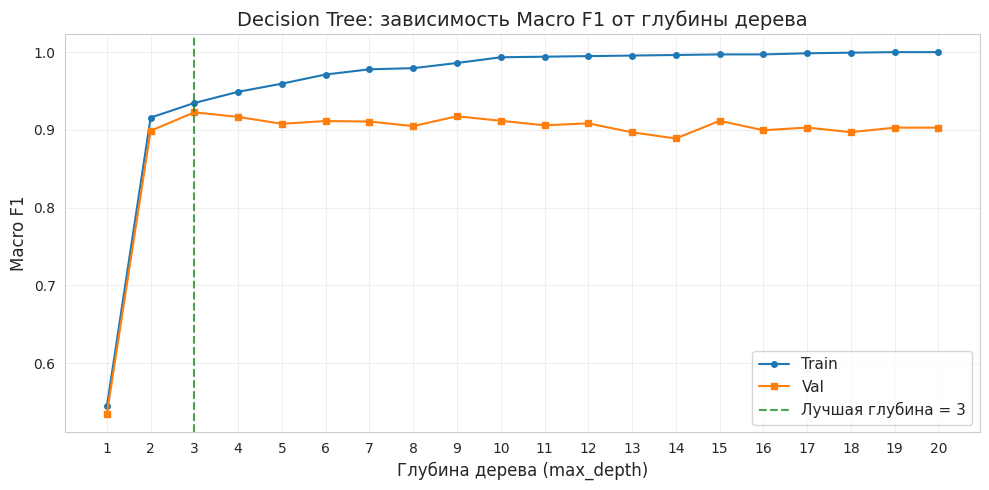

In [10]:
# Визуализация зависимости F1 от глубины дерева
plt.figure(figsize=(10, 5))
plt.plot(df_dt['max_depth'], df_dt['f1_train'], 'o-', label='Train', markersize=4)
plt.plot(df_dt['max_depth'], df_dt['f1_val'], 's-', label='Val', markersize=4)
plt.axvline(x=best_depth, color='green', linestyle='--', alpha=0.7,
            label=f'Лучшая глубина = {best_depth}')
plt.xlabel('Глубина дерева (max_depth)', fontsize=12)
plt.ylabel('Macro F1', fontsize=12)
plt.title('Decision Tree: зависимость Macro F1 от глубины дерева', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

**Вывод:** На графике видно, что после определенного значения с ростом F1 на train, метрика F1 не растет на val, значит дерево начинает переобучаться. Оптимальная глубина находится в точке, где val F1 максимален.

### 5.3 Финальная модель Decision Tree

In [11]:
best_depth = 3

dt_best = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=RANDOM_STATE
)
dt_best.fit(X_train_pca, y_train)

y_pred_dt_val = dt_best.predict(X_val_pca)
y_pred_dt_test = dt_best.predict(X_test_pca)

print(f'Decision Tree (max_depth={best_depth}):')
print(f'  Train - Macro F1: {f1_score(y_train, dt_best.predict(X_train_pca), average="macro"):.4f}')
print(f'  Val   - Macro F1: {f1_score(y_val, y_pred_dt_val, average="macro"):.4f}')
print(f'  Test  - Macro F1: {f1_score(y_test, y_pred_dt_test, average="macro"):.4f}')

Decision Tree (max_depth=3):
  Train - Macro F1: 0.9346
  Val   - Macro F1: 0.9226
  Test  - Macro F1: 0.9288


## 6. Бейзлайн №2: K-Nearest Neighbors (KNN)

Обучим KNN с параметрами по умолчанию, а затем попробуем подобрать количество соседей на валидационной выборке.

### 6.1 KNN с параметрами по умолчанию

In [12]:
knn_default = KNeighborsClassifier()
knn_default.fit(X_train_pca, y_train)

y_pred_knn_train = knn_default.predict(X_train_pca)
y_pred_knn_val = knn_default.predict(X_val_pca)

f1_train = f1_score(y_train, y_pred_knn_train, average='macro')
f1_val = f1_score(y_val, y_pred_knn_val, average='macro')

print(f'Decision Tree (default):')
print(f'  Train - Macro F1: {f1_train:.4f}')
print(f'  Val   - Macro F1: {f1_val:.4f}')
print(f'  Количество соседей: {knn_default.n_neighbors}')

Decision Tree (default):
  Train - Macro F1: 0.9578
  Val   - Macro F1: 0.9350
  Количество соседей: 5


### 6.2 Подбор числа соседей на валидационной выборке

In [13]:
results_knn = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_pca, y_train)

    f1_tr = f1_score(y_train, knn.predict(X_train_pca), average='macro')
    f1_v = f1_score(y_val, knn.predict(X_val_pca), average='macro')
    results_knn.append({'k': k, 'f1_train': f1_tr, 'f1_val': f1_v})

df_knn = pd.DataFrame(results_knn)
best_k = int(df_knn.loc[df_knn['f1_val'].idxmax(), 'k'])
best_knn_f1 = df_knn['f1_val'].max()

print(f'Лучшее k: {best_k}')
print(f'Лучший Macro F1 на val: {best_knn_f1:.4f}')

Лучшее k: 7
Лучший Macro F1 на val: 0.9408


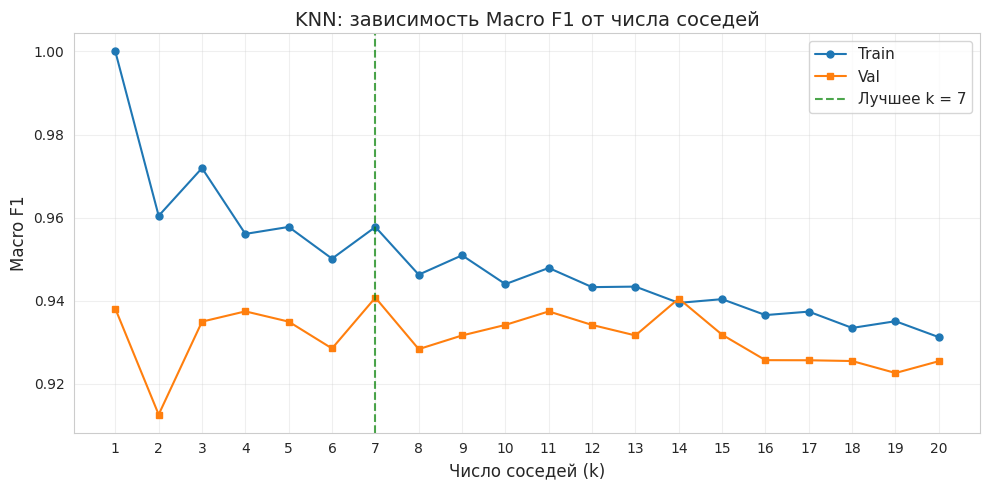

In [14]:
# Визуализация зависимости F1 от k
plt.figure(figsize=(10, 5))
plt.plot(df_knn['k'], df_knn['f1_train'], 'o-', label='Train', markersize=5)
plt.plot(df_knn['k'], df_knn['f1_val'], 's-', label='Val', markersize=5)
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.7,
            label=f'Лучшее k = {best_k}')
plt.xlabel('Число соседей (k)', fontsize=12)
plt.ylabel('Macro F1', fontsize=12)
plt.title('KNN: зависимость Macro F1 от числа соседей', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

**Вывод:** Для KNN также наблюдается bias-variance tradeoff: при k=1 модель переобучается (каждый объект сам себе ближайший сосед на train), при большом k недообучается (слишком сильное усреднение). Оптимальное k балансирует эти два фактора

### 6.3 Финальная модель KNN

In [15]:
best_k = 7

knn_best = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_best.fit(X_train_pca, y_train)

y_pred_knn_val = knn_best.predict(X_val_pca)
y_pred_knn_test = knn_best.predict(X_test_pca)

print(f'KNN (k={best_k}):')
print(f'  Train - Macro F1: {f1_score(y_train, knn_best.predict(X_train_pca), average="macro"):.4f}')
print(f'  Val   - Macro F1: {f1_score(y_val, y_pred_knn_val, average="macro"):.4f}')
print(f'  Test  - Macro F1: {f1_score(y_test, y_pred_knn_test, average="macro"):.4f}')

KNN (k=7):
  Train - Macro F1: 0.9578
  Val   - Macro F1: 0.9408
  Test  - Macro F1: 0.9263


## 7. Сравнение моделей

### 7.1 Сводная таблица результатов

In [16]:
# Собираем результаты в таблицу
results = {
    'Модель': [
        'DummyClassifier (most_frequent)',
        f'Decision Tree (max_depth={best_depth})',
        f'KNN (k={best_k})'
    ],
    'Macro F1 (Train)': [
        f1_score(y_train, dummy.predict(X_train_pca), average='macro'),
        f1_score(y_train, dt_best.predict(X_train_pca), average='macro'),
        f1_score(y_train, knn_best.predict(X_train_pca), average='macro'),
    ],
    'Macro F1 (Val)': [
        f1_score(y_val, dummy.predict(X_val_pca), average='macro'),
        f1_score(y_val, y_pred_dt_val, average='macro'),
        f1_score(y_val, y_pred_knn_val, average='macro'),
    ],
    'Macro F1 (Test)': [
        f1_score(y_test, dummy.predict(X_test_pca), average='macro'),
        f1_score(y_test, y_pred_dt_test, average='macro'),
        f1_score(y_test, y_pred_knn_test, average='macro'),
    ],
}

df_results = pd.DataFrame(results)
df_results.style.highlight_max(
    subset=['Macro F1 (Val)', 'Macro F1 (Test)'],
    color='green'
)

,Модель,Macro F1 (Train),Macro F1 (Val),Macro F1 (Test)
0,DummyClassifier (most_frequent),0.167581,0.168129,0.167251
1,Decision Tree (max_depth=3),0.934609,0.922600,0.928804
2,KNN (k=7),0.957777,0.940778,0.926309


**Вывод:** На тестовой выборке лучший результат показала модель Decision Tree

### 7.2 Матрицы ошибок на тестовой выборке

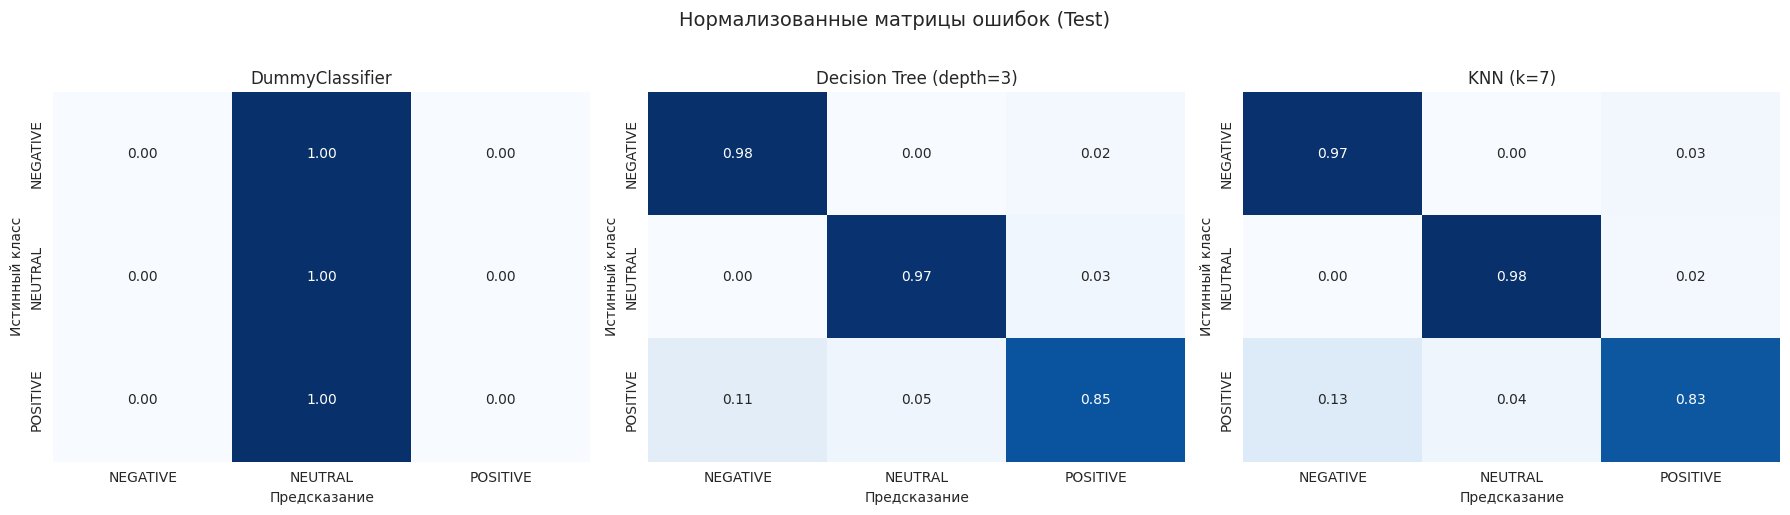

In [17]:
class_names = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [
    ('DummyClassifier', dummy.predict(X_test_pca)),
    (f'Decision Tree (depth={int(best_depth)})', y_pred_dt_test),
    (f'KNN (k={best_k})', y_pred_knn_test)
]):
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истинный класс')

plt.suptitle('Нормализованные матрицы ошибок (Test)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Как видно DecisionTree и KNN обе одинаково хорошо справляются с классами NEGATIVE и NEAUTRAL. И чаще других путают класс POSITIVE с NEGATIVE.

### 7.3 Classification Reports

In [18]:
print(f"Decision Tree (max_depth={best_depth})\n")
print(classification_report(
    y_test, y_pred_dt_test,
    target_names=class_names,
    digits=4
))

Decision Tree (max_depth=3)

              precision    recall  f1-score   support

    NEGATIVE     0.9026    0.9789    0.9392       142
     NEUTRAL     0.9517    0.9650    0.9583       143
    POSITIVE     0.9375    0.8451    0.8889       142

    accuracy                         0.9297       427
   macro avg     0.9306    0.9297    0.9288       427
weighted avg     0.9307    0.9297    0.9289       427



In [19]:
print(f"KNN (k={best_k})\n")
print(classification_report(
    y_test, y_pred_knn_test,
    target_names=class_names,
    digits=4
))

KNN (k=7)

              precision    recall  f1-score   support

    NEGATIVE     0.8846    0.9718    0.9262       142
     NEUTRAL     0.9589    0.9790    0.9689       143
    POSITIVE     0.9440    0.8310    0.8839       142

    accuracy                         0.9274       427
   macro avg     0.9292    0.9273    0.9263       427
weighted avg     0.9292    0.9274    0.9264       427



## 8. Выводы

1. Константный бейзлайн (предсказание наиболее частого класса) даёт Macro F1 ≈ 0.17 - это нижняя граница, которую обе модели значительно превосходят. ну кроме класса NEUTRAL очевидно :)

2. Предобработка играет ключевую роль:
   - Стандартизация необходима для KNN и PCA.
   - PCA снижает размерность с 2548 до 168 компонент (сохраняя 95% информации), что критично для борьбы с переобучением и проклятием размерности.

3. По итогу на тестовой выборке лучшие результаты показала модель Decision Tree (F1 = 0.9288). KNN так же показала близкие результаты (F1 = 0.9263).